# Tarea: Evaluación difusa de riesgo crediticio

## Mario Alejandro Castro Lerma

#### Objetivo

Construir y analizar un sistema de inferencia difusa para estimar el **riesgo crediticio**, utilizando datos reales del dataset  
**German Credit Dataset** (UCI Machine Learning Repository).

El dataset contiene información de solicitantes de crédito, incluyendo:

- duración del crédito  
- monto del préstamo  
- historial crediticio  
- empleo  
- nivel de ahorro  
- estado personal  

Variable objetivo: **Riesgo**

#### Tareas:

- Elegir al menos 3–4 variables relevantes y preprocesarlas para los algoritmos (normalización, discretización, limpieza, etc).
- Definir etiquetas lingüísticas apropiadas para cada variable. 
- Diseñar 6–10 reglas; Justificar cada regla.
- Implementar y comparar los modelos vistos en clase. **Reto Bonus:** explorar otras variantes de FIS.
- Discutir resultados. 

#### Entregables

- Notebook reproducible  
- Visualización de funciones de membresía  
- Tabla comparativa (modelos vs métricas)  
- Discusión técnica  

#### Preparando Dataset

In [137]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml

In [138]:
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'

df = pd.read_csv(URL, sep=' ', header=None)

# Target
df['risk'] = df[20]

df.drop(columns=[20], inplace=True)

print(df.shape)
df.head()

(1000, 21)


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [139]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       1000 non-null   str  
 1   1       1000 non-null   int64
 2   2       1000 non-null   str  
 3   3       1000 non-null   str  
 4   4       1000 non-null   int64
 5   5       1000 non-null   str  
 6   6       1000 non-null   str  
 7   7       1000 non-null   int64
 8   8       1000 non-null   str  
 9   9       1000 non-null   str  
 10  10      1000 non-null   int64
 11  11      1000 non-null   str  
 12  12      1000 non-null   int64
 13  13      1000 non-null   str  
 14  14      1000 non-null   str  
 15  15      1000 non-null   int64
 16  16      1000 non-null   str  
 17  17      1000 non-null   int64
 18  18      1000 non-null   str  
 19  19      1000 non-null   str  
 20  risk    1000 non-null   int64
dtypes: int64(8), str(13)
memory usage: 164.2 KB


In [140]:
df['risk'].value_counts()

risk
1    700
2    300
Name: count, dtype: int64

In [141]:
df['risk'] = df['risk'].map({
    1 : 'bueno',
    2 : 'malo'
})

df['risk'].value_counts()

risk
bueno    700
malo     300
Name: count, dtype: int64

0 = bajo riesgo (es decir bueno)
1 = alto riesgo (es decir malo)

#### Seleccion de columnas:

In [142]:
selected_cols = [
    'duration',
    'credit_history',
    'purpose',
    'credit_amount',
    'risk'
]

credit_df = df[[1, 2, 3, 4, 'risk']].copy()

credit_df.columns = selected_cols

credit_df.head()

,duration,credit_history,purpose,credit_amount,risk
0,6,A34,A43,1169,bueno
1,48,A32,A43,5951,malo
2,12,A34,A46,2096,bueno
3,42,A32,A42,7882,bueno
4,24,A33,A40,4870,malo


In [143]:
credit_df.describe()

,duration,credit_amount
count,1000.000000,1000.000000
mean,20.903000,3271.258000
std,12.058814,2822.736876
min,4.000000,250.000000
25%,12.000000,1365.500000
50%,18.000000,2319.500000
75%,24.000000,3972.250000
max,72.000000,18424.000000


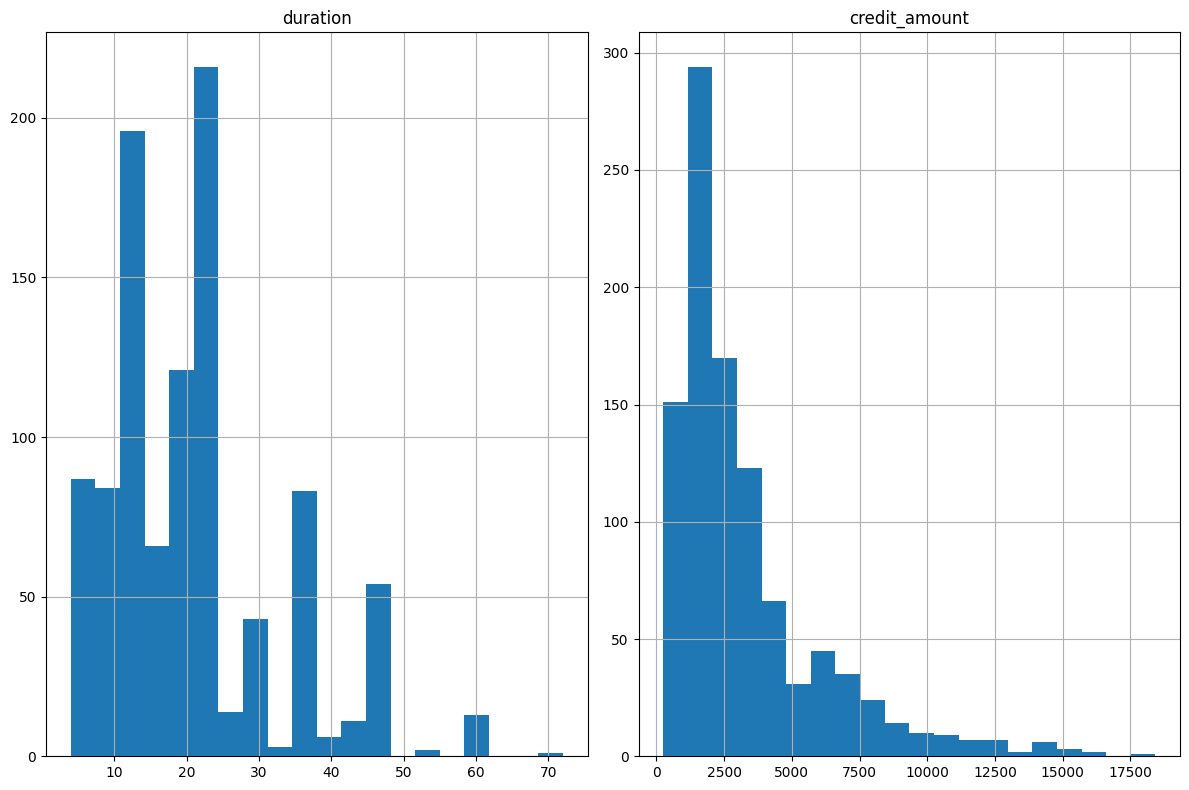

In [144]:
import matplotlib.pyplot as plt

credit_df.hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()

Voy a renombrar las etiquetas para poder entenderlas mejor:

In [145]:
credit_history_map = {
    'A30': 'no_credits_all_paid',
    'A31': 'all_paid_bank',
    'A32': 'current_paid',
    'A33': 'past_delay',
    'A34': 'critical_account'
}

purpose_map = {
    'A40': 'new_car',
    'A41': 'used_car',
    'A42': 'furniture_equipment',
    'A43': 'radio_tv',
    'A44': 'domestic_appliances',
    'A45': 'repairs',
    'A46': 'education',
    'A47': 'vacation',
    'A48': 'retraining',
    'A49': 'business',
    'A410': 'others'
}
credit_df['credit_history'] = (
    credit_df['credit_history']
    .map(credit_history_map)
)

credit_df['purpose'] = (
    credit_df['purpose']
    .map(purpose_map)
)

credit_df.head()

,duration,credit_history,purpose,credit_amount,risk
0,6,critical_account,radio_tv,1169,bueno
1,48,current_paid,radio_tv,5951,malo
2,12,critical_account,education,2096,bueno
3,42,current_paid,furniture_equipment,7882,bueno
4,24,past_delay,new_car,4870,malo


In [146]:
print(credit_df['credit_history'].value_counts())
print()

print(credit_df['purpose'].value_counts())

credit_history
current_paid           530
critical_account       293
past_delay              88
all_paid_bank           49
no_credits_all_paid     40
Name: count, dtype: int64

purpose
radio_tv               280
new_car                234
furniture_equipment    181
used_car               103
business                97
education               50
repairs                 22
domestic_appliances     12
others                  12
retraining               9
Name: count, dtype: int64


### Creando etiquetas para modelarlo:

Primero categoricas:

In [147]:
purpose_group_map = {
    'new_car': 'vehiculo',
    'used_car': 'vehiculo',

    'furniture_equipment': 'hogar',
    'radio_tv': 'hogar',
    'domestic_appliances': 'hogar',
    'repairs': 'hogar',

    'education': 'educacion',
    'retraining': 'educacion',

    'business': 'negocio',

    'others': 'otros'
}
credit_df['purpose_group'] = (
    credit_df['purpose']
    .map(purpose_group_map)
)

credit_df['purpose_group'].value_counts()

purpose_group
hogar        495
vehiculo     337
negocio       97
educacion     59
otros         12
Name: count, dtype: int64

In [148]:
history_linguistic_map = {
    'no_credits_all_paid': 'excelente',
    'all_paid_bank': 'bueno',
    'current_paid': 'estable',
    'past_delay': 'riesgoso',
    'critical_account': 'critico'
}

credit_df['history_label'] = (
    credit_df['credit_history']
    .map(history_linguistic_map)
)
credit_df['history_label'].value_counts()

history_label
estable      530
critico      293
riesgoso      88
bueno         49
excelente     40
Name: count, dtype: int64

Ahora las numericas:

In [149]:
credit_df[['duration', 'credit_amount']].describe()

,duration,credit_amount
count,1000.000000,1000.000000
mean,20.903000,3271.258000
std,12.058814,2822.736876
min,4.000000,250.000000
25%,12.000000,1365.500000
50%,18.000000,2319.500000
75%,24.000000,3972.250000
max,72.000000,18424.000000


Voy a categorizarlo por quartiles

In [150]:
# =========================
# Duration
# =========================

duration_bins = [0, 12, 24, 100]
duration_labels = ['corto', 'medio', 'largo']

credit_df['duration_label'] = pd.cut(
    credit_df['duration'],
    bins=duration_bins,
    labels=duration_labels,
    include_lowest=True
)

# =========================
# Credit Amount
# =========================

amount_bins = [0, 1365, 3973, 20000]
amount_labels = ['bajo', 'medio', 'alto']

credit_df['amount_label'] = pd.cut(
    credit_df['credit_amount'],
    bins=amount_bins,
    labels=amount_labels,
    include_lowest=True
)

# Ver resultados
credit_df.head()

,duration,credit_history,purpose,credit_amount,risk,purpose_group,history_label,duration_label,amount_label
0,6,critical_account,radio_tv,1169,bueno,hogar,critico,corto,bajo
1,48,current_paid,radio_tv,5951,malo,hogar,estable,largo,alto
2,12,critical_account,education,2096,bueno,educacion,critico,corto,medio
3,42,current_paid,furniture_equipment,7882,bueno,hogar,estable,largo,alto
4,24,past_delay,new_car,4870,malo,vehiculo,riesgoso,medio,alto


In [151]:
print(credit_df['duration_label'].value_counts())
print()

print(credit_df['amount_label'].value_counts())

duration_label
medio    411
corto    359
largo    230
Name: count, dtype: int64

amount_label
medio    501
bajo     250
alto     249
Name: count, dtype: int64


| Variable         | Tipo original | Valor/Código original      | Significado                  | Etiqueta |
| ---------------- | ------------- | -------------------------- | ------------------------------------------ | ----------------------------- |
| `duration`       | Numérica      | 0 – 12 meses               | Crédito corto                              | `corto`                       |
| `duration`       | Numérica      | 12 – 24 meses              | Crédito medio                              | `medio`                      |
| `duration`       | Numérica      | 24 – 72 meses              | Crédito largo                              | `largo`                        |
| `credit_amount`  | Numérica      | 0 – 1365                   | Monto bajo                                 | `bajo`                         |
| `credit_amount`  | Numérica      | 1365 – 3972                | Monto medio                                | `medio`                      |
| `credit_amount`  | Numérica      | 3972 – 18424               | Monto alto                                 | `alto`                        |
| `credit_history` | Categórica    | `A30`                      | Sin créditos / todos pagados               | `excelente`                   |
| `credit_history` | Categórica    | `A31`                      | Todos pagados en este banco                | `bueno`                        |
| `credit_history` | Categórica    | `A32`                      | Créditos actuales pagados correctamente    | `estable`                      |
| `credit_history` | Categórica    | `A33`                      | Retrasos de pago previos                   | `riesgoso`                       |
| `credit_history` | Categórica    | `A34`                      | Cuenta crítica / otros créditos existentes | `critico`                    |
| `purpose`        | Categórica    | `A40`, `A41`               | Vehículos                                  | `vehiculo`                     |
| `purpose`        | Categórica    | `A42`, `A43`, `A44`, `A45` | Hogar/equipamiento/reparaciones            | `casa`                        |
| `purpose`        | Categórica    | `A46`, `A48`               | Educación/reentrenamiento                  | `educacion`                   |
| `purpose`        | Categórica    | `A49`                      | Negocio                                    | `negocio`                    |
| `purpose`        | Categórica    | `A47`, `A410`              | Otros propósitos                           | `otro`                       |
| `risk`           | Objetivo      | `1`                        | Bajo riesgo crediticio                     | `bueno`                    |
| `risk`           | Objetivo      | `2`                        | Alto riesgo crediticio                     | `malo`                   |


### Diseño de reglas:

| Regla                                                                                   | Resultado de Riesgo | Justificación                                                                                                                                                 |
| --------------------------------------------------------------------------------------- | ------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|1.  IF `credit_history` IS `critico` AND `credit_amount` IS `alto`   | Alto                | Un historial crediticio crítico combinado con un préstamo de alto monto representa una elevada probabilidad de incumplimiento financiero.                     |
|2.  IF `credit_history` IS `riesgoso` AND `duration` IS `largo`           | Alto                | Los antecedentes de retrasos en pagos y los créditos de larga duración incrementan la incertidumbre de recuperación del préstamo.                             |
|3.  IF `credit_history` IS `excelente` AND `duration` IS `corto`       | Bajo                | Un cliente con excelente historial y un crédito de corta duración presenta bajo nivel de exposición financiera.                                               |
|4.  IF `credit_amount` IS `bajo` AND `duration` IS `corto`              | Bajo                | Los préstamos pequeños y de corto plazo suelen ser más fáciles de liquidar y representan menor riesgo crediticio.                                             |
|5.  IF `purpose` IS `negocio` AND `credit_amount` IS `alto`           | Alto                | Los préstamos empresariales de alto monto poseen mayor volatilidad y riesgo económico.                                                                        |
|6.  IF `purpose` IS `educacion` AND `credit_history` IS `bueno`          | Bajo                | Los créditos educativos, junto con un historial positivo, tienden a asociarse con perfiles financieros más estables.                                          |
|7.  IF `credit_history` IS `estable` AND `credit_amount` IS `medio`  | Medio               | Un historial estable reduce el riesgo, aunque un monto moderado todavía implica cierta incertidumbre financiera.                                              |
|8.  IF `duration` IS `largo` AND `credit_amount` IS `alto`              | Alto                | Los créditos de gran monto y larga duración incrementan significativamente el compromiso financiero del solicitante.                                          |
|9.  IF `purpose` IS `hogar` AND `credit_history` IS `excelente`          | Bajo                | Los préstamos relacionados con vivienda o equipamiento suelen ser más estables cuando el solicitante posee buen historial crediticio.                         |
|10.  IF `credit_history` IS `critico`                                  | Alto                | El historial crediticio es uno de los principales indicadores de riesgo; un estado crítico es suficiente para considerar alta probabilidad de incumplimiento. |
